<a href="https://colab.research.google.com/github/lokesh8008756/lokesh8008756/blob/main/linearregression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
import pandas as pd
from sklearn.datasets import fetch_california_housing
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [18]:
california_data=fetch_california_housing()
california_df=pd.DataFrame(california_data.data,columns=california_data.feature_names)

In [21]:
california_df['target']=california_data.target

In [23]:
print(california_df.head(50))

    MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0   8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1   8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2   7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3   5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4   3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   
5   4.0368      52.0  4.761658   1.103627       413.0  2.139896     37.85   
6   3.6591      52.0  4.931907   0.951362      1094.0  2.128405     37.84   
7   3.1200      52.0  4.797527   1.061824      1157.0  1.788253     37.84   
8   2.0804      42.0  4.294118   1.117647      1206.0  2.026891     37.84   
9   3.6912      52.0  4.970588   0.990196      1551.0  2.172269     37.84   
10  3.2031      52.0  5.477612   1.079602       910.0  2.263682     37.85   
11  3.2705      52.0  4.772480   1.024523      1504.0  2.049046     37.85   

In [32]:
x=california_df.drop('target',axis=1)
y=california_df['target']

In [33]:
from sklearn.model_selection import train_test_split

In [36]:
x_train, x_test, y_train,y_test=train_test_split(x,y,test_size=0.30,random_state=42)

In [37]:
x_train

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
7061,4.1312,35.0,5.882353,0.975490,1218.0,2.985294,33.93,-118.02
14689,2.8631,20.0,4.401210,1.076613,999.0,2.014113,32.79,-117.09
17323,4.2026,24.0,5.617544,0.989474,731.0,2.564912,34.59,-120.14
10056,3.1094,14.0,5.869565,1.094203,302.0,2.188406,39.26,-121.00
15750,3.3068,52.0,4.801205,1.066265,1526.0,2.298193,37.77,-122.45
...,...,...,...,...,...,...,...,...
11284,6.3700,35.0,6.129032,0.926267,658.0,3.032258,33.78,-117.96
11964,3.0500,33.0,6.868597,1.269488,1753.0,3.904232,34.02,-117.43
5390,2.9344,36.0,3.986717,1.079696,1756.0,3.332068,34.03,-118.38
860,5.7192,15.0,6.395349,1.067979,1777.0,3.178891,37.58,-121.96


In [40]:
from sklearn.preprocessing import StandardScaler

In [41]:
scaler=StandardScaler()

In [43]:
x_train=scaler.fit_transform(x_train)

In [44]:
x_test=scaler.transform(x_test)

: This ensures that both your training and test data are on the same scale, improving the performance and reliability of your machine learning model.









In [46]:
from sklearn.linear_model import LinearRegression
##cross validation
from sklearn.model_selection import cross_val_score

In [55]:
regression=LinearRegression()
mse=cross_val_score(regression,x_train,y_train,scoring='neg_mean_squared_error',cv=10)

In [58]:
regression.fit(x_train, y_train)
reg_pred=regression.predict(x_test)

In [59]:
reg_pred

array([0.72604907, 1.76743383, 2.71092161, ..., 2.07465531, 1.57371395,
       1.82744133])

<ipython-input-63-c0c48e7e589a>:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(reg_pred-y_test)


<Axes: xlabel='target', ylabel='Density'>

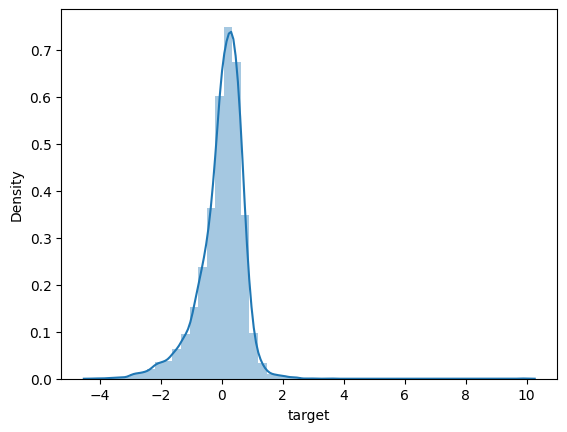

In [63]:
import seaborn as sns
sns.distplot(reg_pred-y_test)

In [64]:
from sklearn.metrics import r2_score

In [65]:
score=r2_score(reg_pred,y_test)

In [66]:
score

0.3451339380943961